# 02. Análisis Exploratorio de Datos Gold

Este notebook analiza los CSV exportados desde la capa **Gold**.  
No consulta directamente Supabase, para evitar recalcular vistas pesadas o generar timeouts.

## 1. Importar librerías

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Cargar archivos exportados desde Gold

In [2]:
# Detectar automáticamente la raíz del proyecto.
# Funciona si ejecutas el notebook desde /notebooks o desde la raíz del proyecto.
cwd = Path.cwd()

if (cwd / "data" / "processed").exists():
    ROOT_DIR = cwd
elif (cwd.parent / "data" / "processed").exists():
    ROOT_DIR = cwd.parent
else:
    raise FileNotFoundError(
        "No se encontró la carpeta data/processed. "
        "Ejecuta primero el notebook 01_extract_gold_data_actualizado.ipynb."
    )

DATA_DIR = ROOT_DIR / "data" / "processed"

archivos_requeridos = {
    "predictivo": DATA_DIR / "gold_modelo_predictivo.csv",
    "mensual": DATA_DIR / "gold_semaforo_asesor_mes.csv",
    "mejora": DATA_DIR / "gold_puntos_mejora_asesor.csv",
}

for nombre, ruta in archivos_requeridos.items():
    if not ruta.exists():
        raise FileNotFoundError(f"No existe el archivo requerido: {ruta}")

df_predictivo = pd.read_csv(archivos_requeridos["predictivo"], dtype={"dni": str})
df_mensual = pd.read_csv(archivos_requeridos["mensual"], dtype={"dni": str})
df_mejora = pd.read_csv(archivos_requeridos["mejora"], dtype={"dni": str})

print("Predictivo:", df_predictivo.shape)
print("Mensual:", df_mensual.shape)
print("Mejora:", df_mejora.shape)
print("\nCarpeta de datos:", DATA_DIR)

Predictivo: (1620, 37)
Mensual: (1680, 34)
Mejora: (10080, 12)

Carpeta de datos: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\data\processed


## 3. Revisión inicial de tablas

In [3]:
df_predictivo.head()

,dni,asesor,area,sede,fecha_ingreso,estado_trabajador,anio,mes,periodo,aprobacion_inmediata_pct,horas_conexion_acumulado,horas_conexion_pct,tmo_minutos,nps_pct,calidad_pct,tipificacion_crm_pct,nota_examen,atendidas,reg_crm,nc_aprobacion,nc_horas_conexion,nc_tmo,nc_nps,nc_calidad,nc_tipificacion,alerta_aprobacion,alerta_horas_conexion,alerta_tmo,alerta_nps,alerta_calidad,alerta_tipificacion,score_final,semaforo_actual,tmo_original_bronze,semaforo_mes_siguiente,score_mes_siguiente,periodo_siguiente
0,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,1,2024-01,45.0,164.422778,79.397222,6.059500,76.94,77.400000,86.944444,14.000000,18222.0,15854.0,0.0,0.0,0.00,150.0,37.00,69.44,Crítico,Crítico,Crítico,Adecuado,Crítico,Crítico,53.69,Rojo,6.87,Rojo,69.06,2024-02
1,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,2,2024-02,55.0,155.915556,81.311667,5.852500,72.34,82.857143,85.937500,14.928571,14498.0,12332.0,150.0,0.0,14.75,116.4,64.29,59.38,Adecuado,Crítico,Crítico,Adecuado,Crítico,Crítico,69.06,Rojo,6.67,Ámbar,71.91,2024-03
2,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,3,2024-03,50.0,169.732308,81.960769,5.847222,77.88,79.722222,89.200000,14.500000,13653.0,12130.0,100.0,0.0,15.28,150.0,48.61,92.00,Adecuado,Crítico,Crítico,Adecuado,Crítico,Por mejorar,71.91,Ámbar,6.94,Rojo,65.96,2024-04
3,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,4,2024-04,45.0,157.763333,79.110952,5.749333,75.59,81.315789,89.578947,14.684211,18993.0,17017.0,0.0,0.0,25.07,148.9,56.58,95.79,Crítico,Crítico,Crítico,Adecuado,Crítico,Por mejorar,65.96,Rojo,6.98,Rojo,24.11,2024-05
4,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,5,2024-05,45.0,171.303529,82.719412,5.888824,61.94,81.470588,84.444444,15.058824,14130.0,11869.0,0.0,0.0,11.12,12.4,57.35,44.44,Crítico,Crítico,Crítico,Crítico,Crítico,Crítico,24.11,Rojo,6.84,Ámbar,85.85,2024-06


In [4]:
df_mensual.head()

,dni,asesor,area,sede,fecha_ingreso,estado_trabajador,anio,mes,periodo,aprobacion_inmediata_pct,horas_conexion_acumulado,horas_conexion_pct,tmo_minutos,nps_pct,calidad_pct,tipificacion_crm_pct,nota_examen,atendidas,reg_crm,nc_aprobacion,nc_horas_conexion,nc_tmo,nc_nps,nc_calidad,nc_tipificacion,alerta_aprobacion,alerta_horas_conexion,alerta_tmo,alerta_nps,alerta_calidad,alerta_tipificacion,score_final,semaforo_actual,tmo_original_bronze
0,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,1,2024-01,45.0,164.422778,79.397222,6.059500,76.94,77.400000,86.944444,14.000000,18222.0,15854.0,0.0,0.0,0.00,150.0,37.00,69.44,Crítico,Crítico,Crítico,Adecuado,Crítico,Crítico,53.69,Rojo,6.87
1,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,2,2024-02,55.0,155.915556,81.311667,5.852500,72.34,82.857143,85.937500,14.928571,14498.0,12332.0,150.0,0.0,14.75,116.4,64.29,59.38,Adecuado,Crítico,Crítico,Adecuado,Crítico,Crítico,69.06,Rojo,6.67
2,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,3,2024-03,50.0,169.732308,81.960769,5.847222,77.88,79.722222,89.200000,14.500000,13653.0,12130.0,100.0,0.0,15.28,150.0,48.61,92.00,Adecuado,Crítico,Crítico,Adecuado,Crítico,Por mejorar,71.91,Ámbar,6.94
3,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,4,2024-04,45.0,157.763333,79.110952,5.749333,75.59,81.315789,89.578947,14.684211,18993.0,17017.0,0.0,0.0,25.07,148.9,56.58,95.79,Crítico,Crítico,Crítico,Adecuado,Crítico,Por mejorar,65.96,Rojo,6.98
4,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,5,2024-05,45.0,171.303529,82.719412,5.888824,61.94,81.470588,84.444444,15.058824,14130.0,11869.0,0.0,0.0,11.12,12.4,57.35,44.44,Crítico,Crítico,Crítico,Crítico,Crítico,Crítico,24.11,Rojo,6.84


In [5]:
df_mejora.head()

,dni,asesor,anio,mes,periodo,indicador,valor_original,nivel_cumplimiento,nivel_alerta,peso_indicador,recomendacion,prioridad_mejora
0,40107223,María Rodríguez Morales,2024,1,2024-01,TMO,6.059500,0.00,Crítico,0.20,"Mejorar guion de atención, reducir tiempos mue...",1
1,40107223,María Rodríguez Morales,2024,1,2024-01,Aprobación inmediata,45.000000,0.00,Crítico,0.10,"Revisar criterios de aprobación, validación do...",2
2,40107223,María Rodríguez Morales,2024,1,2024-01,Horas conexión,79.397222,0.00,Crítico,0.10,"Controlar puntualidad, pausas, desconexiones y...",3
3,40107223,María Rodríguez Morales,2024,1,2024-01,Calidad,77.400000,37.00,Crítico,0.25,"Reforzar protocolo de atención, validación de ...",4
4,40107223,María Rodríguez Morales,2024,1,2024-01,Tipificación CRM,86.944444,69.44,Crítico,0.10,"Capacitar en registro correcto, codificación d...",5


## 4. Columnas disponibles

In [6]:
print("Columnas df_predictivo:")
print(df_predictivo.columns.tolist())

print("\nColumnas df_mensual:")
print(df_mensual.columns.tolist())

print("\nColumnas df_mejora:")
print(df_mejora.columns.tolist())

Columnas df_predictivo:
['dni', 'asesor', 'area', 'sede', 'fecha_ingreso', 'estado_trabajador', 'anio', 'mes', 'periodo', 'aprobacion_inmediata_pct', 'horas_conexion_acumulado', 'horas_conexion_pct', 'tmo_minutos', 'nps_pct', 'calidad_pct', 'tipificacion_crm_pct', 'nota_examen', 'atendidas', 'reg_crm', 'nc_aprobacion', 'nc_horas_conexion', 'nc_tmo', 'nc_nps', 'nc_calidad', 'nc_tipificacion', 'alerta_aprobacion', 'alerta_horas_conexion', 'alerta_tmo', 'alerta_nps', 'alerta_calidad', 'alerta_tipificacion', 'score_final', 'semaforo_actual', 'tmo_original_bronze', 'semaforo_mes_siguiente', 'score_mes_siguiente', 'periodo_siguiente']

Columnas df_mensual:
['dni', 'asesor', 'area', 'sede', 'fecha_ingreso', 'estado_trabajador', 'anio', 'mes', 'periodo', 'aprobacion_inmediata_pct', 'horas_conexion_acumulado', 'horas_conexion_pct', 'tmo_minutos', 'nps_pct', 'calidad_pct', 'tipificacion_crm_pct', 'nota_examen', 'atendidas', 'reg_crm', 'nc_aprobacion', 'nc_horas_conexion', 'nc_tmo', 'nc_nps', 'nc

## 5. Validación de columnas clave

In [7]:
columnas_clave_predictivo = [
    "dni", "asesor", "anio", "mes", "periodo",
    "score_final", "semaforo_actual",
    "semaforo_mes_siguiente"
]

columnas_clave_mensual = [
    "dni", "asesor", "anio", "mes", "periodo",
    "score_final", "semaforo_actual"
]

columnas_clave_mejora = [
    "dni", "asesor", "anio", "mes", "periodo",
    "indicador", "valor_original", "nivel_cumplimiento",
    "nivel_alerta", "prioridad_mejora", "recomendacion"
]

def revisar_columnas(df, columnas, nombre_df):
    faltantes = [col for col in columnas if col not in df.columns]
    if faltantes:
        print(f"Columnas faltantes en {nombre_df}: {faltantes}")
    else:
        print(f"OK: {nombre_df} contiene las columnas clave.")

revisar_columnas(df_predictivo, columnas_clave_predictivo, "df_predictivo")
revisar_columnas(df_mensual, columnas_clave_mensual, "df_mensual")
revisar_columnas(df_mejora, columnas_clave_mejora, "df_mejora")

OK: df_predictivo contiene las columnas clave.
OK: df_mensual contiene las columnas clave.
OK: df_mejora contiene las columnas clave.


## 6. Preparación ligera para análisis

In [8]:
# Ordenar por periodo cuando exista.
for df in [df_predictivo, df_mensual, df_mejora]:
    if "periodo" in df.columns:
        df["periodo"] = df["periodo"].astype(str)

if {"dni", "periodo"}.issubset(df_predictivo.columns):
    df_predictivo = df_predictivo.sort_values(["dni", "periodo"]).reset_index(drop=True)

if {"dni", "periodo"}.issubset(df_mensual.columns):
    df_mensual = df_mensual.sort_values(["dni", "periodo"]).reset_index(drop=True)

if {"dni", "periodo", "prioridad_mejora"}.issubset(df_mejora.columns):
    df_mejora = df_mejora.sort_values(["dni", "periodo", "prioridad_mejora"]).reset_index(drop=True)

# Variables numéricas esperadas en Gold.
variables_numericas_esperadas = [
    "aprobacion_inmediata_pct",
    "horas_conexion_acumulado",
    "horas_conexion_pct",
    "tmo_minutos",
    "nps_pct",
    "calidad_pct",
    "tipificacion_crm_pct",
    "nota_examen",
    "atendidas",
    "reg_crm",
    "nc_aprobacion",
    "nc_horas_conexion",
    "nc_tmo",
    "nc_nps",
    "nc_calidad",
    "nc_tipificacion",
    "score_final",
]

variables_numericas = [col for col in variables_numericas_esperadas if col in df_mensual.columns]

print("Variables numéricas disponibles:")
print(variables_numericas)

Variables numéricas disponibles:
['aprobacion_inmediata_pct', 'horas_conexion_acumulado', 'horas_conexion_pct', 'tmo_minutos', 'nps_pct', 'calidad_pct', 'tipificacion_crm_pct', 'nota_examen', 'atendidas', 'reg_crm', 'nc_aprobacion', 'nc_horas_conexion', 'nc_tmo', 'nc_nps', 'nc_calidad', 'nc_tipificacion', 'score_final']


## 7. Revisión de valores nulos

In [9]:
nulos_predictivo = df_predictivo.isnull().sum().sort_values(ascending=False)
nulos_predictivo[nulos_predictivo > 0]

Series([], dtype: int64)

In [10]:
nulos_mensual = df_mensual.isnull().sum().sort_values(ascending=False)
nulos_mensual[nulos_mensual > 0]

Series([], dtype: int64)

## 8. Nulos en indicadores clave

In [11]:
indicadores_clave = [
    col for col in [
        "aprobacion_inmediata_pct",
        "horas_conexion_acumulado",
        "horas_conexion_pct",
        "tmo_minutos",
        "nps_pct",
        "calidad_pct",
        "tipificacion_crm_pct",
        "nc_aprobacion",
        "nc_horas_conexion",
        "nc_tmo",
        "nc_nps",
        "nc_calidad",
        "nc_tipificacion",
        "score_final",
        "semaforo_actual",
        "semaforo_mes_siguiente",
    ]
    if col in df_predictivo.columns
]

df_predictivo[indicadores_clave].isnull().sum()

aprobacion_inmediata_pct    0
horas_conexion_acumulado    0
horas_conexion_pct          0
tmo_minutos                 0
nps_pct                     0
calidad_pct                 0
tipificacion_crm_pct        0
nc_aprobacion               0
nc_horas_conexion           0
nc_tmo                      0
nc_nps                      0
nc_calidad                  0
nc_tipificacion             0
score_final                 0
semaforo_actual             0
semaforo_mes_siguiente      0
dtype: int64

## 9. Distribución del semáforo actual

In [12]:
conteo_actual = df_mensual["semaforo_actual"].value_counts(dropna=False)
conteo_actual

semaforo_actual
Rojo     1084
Ámbar     596
Name: count, dtype: int64

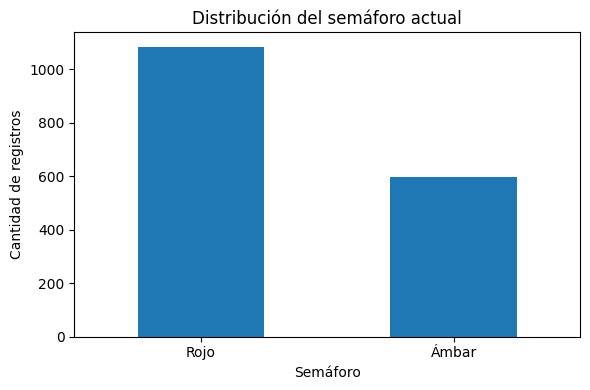

In [13]:
plt.figure(figsize=(6, 4))
conteo_actual.plot(kind="bar")
plt.title("Distribución del semáforo actual")
plt.xlabel("Semáforo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Distribución de la variable objetivo

In [14]:
conteo_objetivo = df_predictivo["semaforo_mes_siguiente"].value_counts(dropna=False)
conteo_objetivo

semaforo_mes_siguiente
Rojo     1068
Ámbar     552
Name: count, dtype: int64

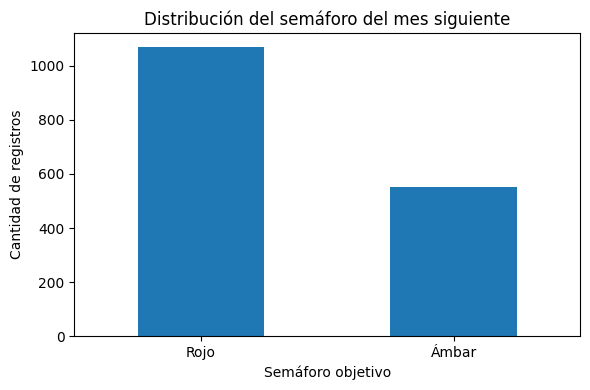

In [15]:
plt.figure(figsize=(6, 4))
conteo_objetivo.plot(kind="bar")
plt.title("Distribución del semáforo del mes siguiente")
plt.xlabel("Semáforo objetivo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Distribución mensual del semáforo

In [16]:
periodo_col = "periodo" if "periodo" in df_mensual.columns else "mes"

tabla_periodo_semaforo = pd.crosstab(
    df_mensual[periodo_col],
    df_mensual["semaforo_actual"]
)

tabla_periodo_semaforo

semaforo_actual,Rojo,Ámbar
periodo,,
2024-01,16,44
2024-02,37,23
2024-03,16,44
2024-04,22,38
2024-05,60,0
2024-06,20,40
2024-07,19,41
2024-08,19,41
2024-09,60,0


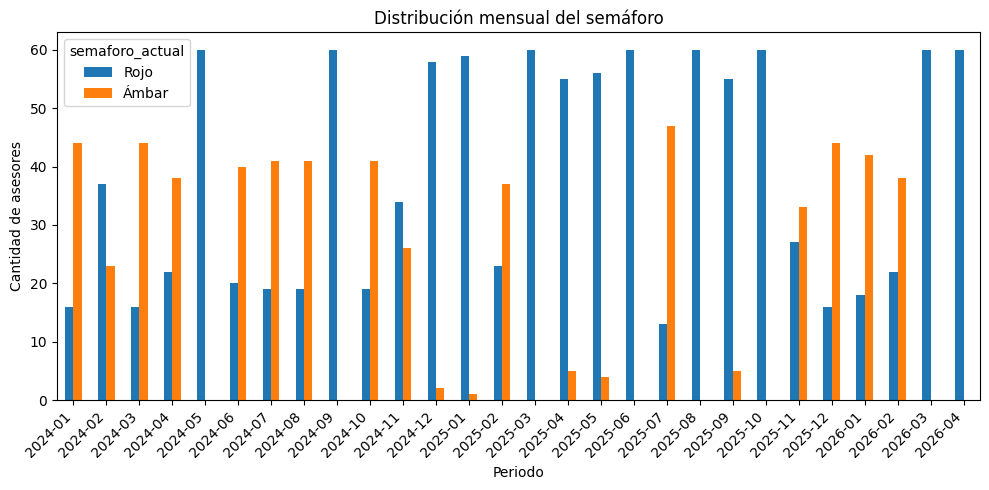

In [17]:
tabla_periodo_semaforo.plot(kind="bar", figsize=(10, 5))
plt.title("Distribución mensual del semáforo")
plt.xlabel("Periodo")
plt.ylabel("Cantidad de asesores")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Resumen del score por periodo

In [18]:
score_mensual = df_mensual.groupby(periodo_col)["score_final"].agg(
    score_promedio="mean",
    score_minimo="min",
    score_maximo="max",
    score_mediana="median"
).round(2)

score_mensual

,score_promedio,score_minimo,score_maximo,score_mediana
periodo,,,,
2024-01,74.44,53.69,89.88,73.32
2024-02,66.09,39.26,81.01,69.04
2024-03,74.70,58.33,92.73,74.48
2024-04,72.98,49.98,88.75,74.48
2024-05,41.21,20.34,55.93,41.72
2024-06,75.25,57.89,92.15,75.78
2024-07,73.89,51.49,89.88,74.10
2024-08,73.04,53.23,90.98,74.56
2024-09,38.43,16.91,53.73,36.89


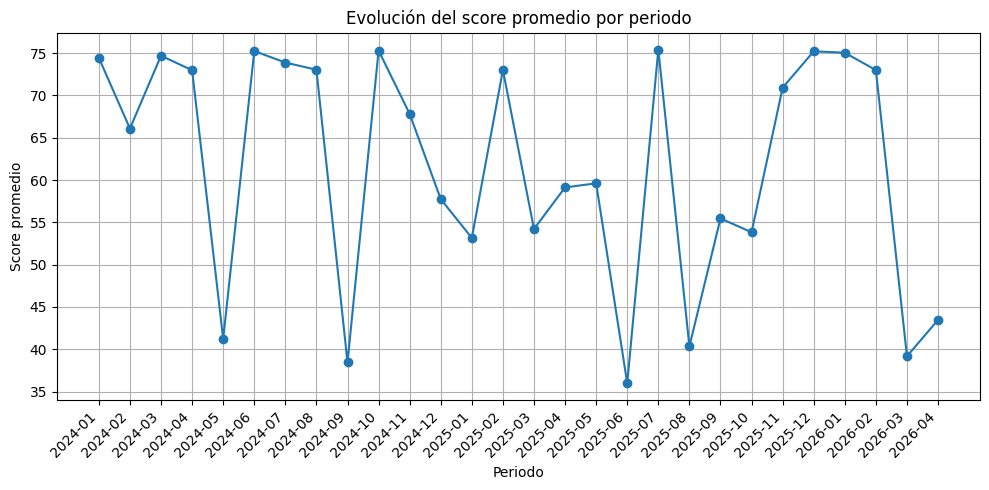

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(score_mensual.index, score_mensual["score_promedio"], marker="o")
plt.title("Evolución del score promedio por periodo")
plt.xlabel("Periodo")
plt.ylabel("Score promedio")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Estadísticas de indicadores principales

In [20]:
df_mensual[variables_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
aprobacion_inmediata_pct,1680.0,49.95,3.76,45.00,45.00,50.00,55.00,55.00
horas_conexion_acumulado,1680.0,185.22,14.35,141.75,174.28,190.26,196.54,200.04
horas_conexion_pct,1680.0,91.50,6.42,76.32,93.88,94.78,95.24,96.63
tmo_minutos,1680.0,5.96,0.12,5.48,5.88,5.96,6.04,6.40
nps_pct,1680.0,71.21,6.10,60.76,67.26,72.50,76.95,78.94
calidad_pct,1680.0,79.66,3.17,68.59,77.54,79.68,81.77,93.60
tipificacion_crm_pct,1680.0,87.61,1.92,81.23,86.32,87.67,88.89,95.09
nota_examen,1680.0,14.50,0.70,12.14,14.04,14.50,15.00,17.60
atendidas,1680.0,24074.56,4792.13,6161.00,24542.75,26129.50,27063.50,29697.00
reg_crm,1680.0,21077.52,4227.49,5588.00,21152.25,22821.50,23748.00,27085.00


## 14. Promedio de indicadores por semáforo

In [21]:
promedio_por_semaforo = df_mensual.groupby("semaforo_actual")[variables_numericas].mean().round(2)
promedio_por_semaforo

,aprobacion_inmediata_pct,horas_conexion_acumulado,horas_conexion_pct,tmo_minutos,nps_pct,calidad_pct,tipificacion_crm_pct,nota_examen,atendidas,reg_crm,nc_aprobacion,nc_horas_conexion,nc_tmo,nc_nps,nc_calidad,nc_tipificacion,score_final
semaforo_actual,,,,,,,,,,,,,,,,,
Rojo,49.07,183.67,90.54,5.97,68.37,79.22,87.48,14.41,23395.55,20449.98,70.85,68.73,6.43,73.68,46.13,74.31,52.63
Ámbar,51.54,188.06,93.24,5.94,76.37,80.45,87.86,14.67,25309.55,22218.88,110.82,86.50,8.11,143.96,52.25,78.14,78.22


## 15. Indicadores críticos más frecuentes

In [22]:
if "nivel_alerta" in df_mejora.columns:
    criticos = df_mejora[df_mejora["nivel_alerta"].astype(str).str.lower() == "crítico"].copy()
else:
    criticos = pd.DataFrame()

if criticos.empty:
    print("No se encontraron indicadores en nivel Crítico.")
else:
    display(criticos["indicador"].value_counts())

indicador
TMO                     1680
Calidad                 1545
Tipificación CRM         621
Aprobación inmediata     485
NPS                      480
Horas conexión           393
Name: count, dtype: int64

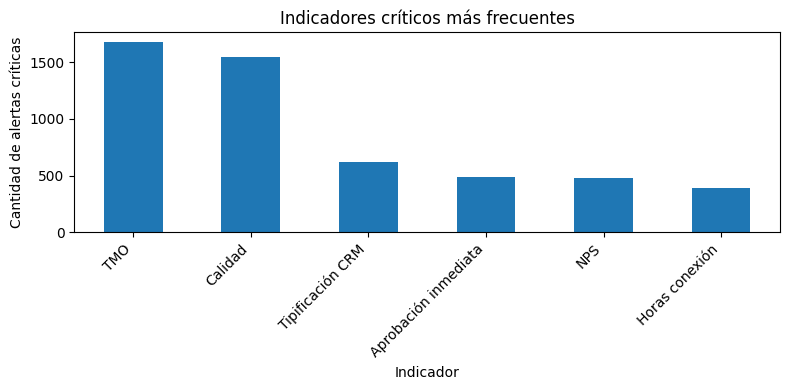

In [23]:
if not criticos.empty:
    conteo_criticos = criticos["indicador"].value_counts()

    plt.figure(figsize=(8, 4))
    conteo_criticos.plot(kind="bar")
    plt.title("Indicadores críticos más frecuentes")
    plt.xlabel("Indicador")
    plt.ylabel("Cantidad de alertas críticas")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 16. Top 3 puntos de mejora por asesor

In [24]:
if "prioridad_mejora" in df_mejora.columns:
    top3_mejoras = df_mejora[df_mejora["prioridad_mejora"] <= 3].copy()
else:
    top3_mejoras = df_mejora.copy()

top3_mejoras.head(10)

,dni,asesor,anio,mes,periodo,indicador,valor_original,nivel_cumplimiento,nivel_alerta,peso_indicador,recomendacion,prioridad_mejora
0,40107223,María Rodríguez Morales,2024,1,2024-01,TMO,6.059500,0.00,Crítico,0.20,"Mejorar guion de atención, reducir tiempos mue...",1
1,40107223,María Rodríguez Morales,2024,1,2024-01,Aprobación inmediata,45.000000,0.00,Crítico,0.10,"Revisar criterios de aprobación, validación do...",2
2,40107223,María Rodríguez Morales,2024,1,2024-01,Horas conexión,79.397222,0.00,Crítico,0.10,"Controlar puntualidad, pausas, desconexiones y...",3
6,40107223,María Rodríguez Morales,2024,2,2024-02,Horas conexión,81.311667,0.00,Crítico,0.10,"Controlar puntualidad, pausas, desconexiones y...",1
7,40107223,María Rodríguez Morales,2024,2,2024-02,TMO,5.852500,14.75,Crítico,0.20,"Mejorar guion de atención, reducir tiempos mue...",2
8,40107223,María Rodríguez Morales,2024,2,2024-02,Tipificación CRM,85.937500,59.38,Crítico,0.10,"Capacitar en registro correcto, codificación d...",3
12,40107223,María Rodríguez Morales,2024,3,2024-03,Horas conexión,81.960769,0.00,Crítico,0.10,"Controlar puntualidad, pausas, desconexiones y...",1
13,40107223,María Rodríguez Morales,2024,3,2024-03,TMO,5.847222,15.28,Crítico,0.20,"Mejorar guion de atención, reducir tiempos mue...",2
14,40107223,María Rodríguez Morales,2024,3,2024-03,Calidad,79.722222,48.61,Crítico,0.25,"Reforzar protocolo de atención, validación de ...",3
18,40107223,María Rodríguez Morales,2024,4,2024-04,Horas conexión,79.110952,0.00,Crítico,0.10,"Controlar puntualidad, pausas, desconexiones y...",1


In [25]:
if "indicador" in top3_mejoras.columns:
    top3_mejoras["indicador"].value_counts()

## 17. Correlación entre variables numéricas

In [26]:
corr = df_mensual[variables_numericas].corr().round(2)
corr

,aprobacion_inmediata_pct,horas_conexion_acumulado,horas_conexion_pct,tmo_minutos,nps_pct,calidad_pct,tipificacion_crm_pct,nota_examen,atendidas,reg_crm,nc_aprobacion,nc_horas_conexion,nc_tmo,nc_nps,nc_calidad,nc_tipificacion,score_final
aprobacion_inmediata_pct,1.00,-0.03,-0.03,0.00,0.02,0.01,0.03,0.01,-0.03,-0.03,0.98,-0.04,0.00,0.02,0.01,0.03,0.37
horas_conexion_acumulado,-0.03,1.00,0.91,0.02,-0.04,0.04,0.02,0.04,0.84,0.84,-0.01,0.90,-0.06,-0.06,0.04,0.03,0.19
horas_conexion_pct,-0.03,0.91,1.00,0.01,0.00,0.03,0.00,0.04,0.93,0.93,-0.02,0.99,-0.06,0.00,0.03,0.01,0.26
tmo_minutos,0.00,0.02,0.01,1.00,-0.00,-0.01,-0.05,-0.02,-0.00,-0.01,0.00,-0.00,-0.90,-0.01,-0.01,-0.05,-0.11
nps_pct,0.02,-0.04,0.00,-0.00,1.00,-0.02,-0.02,-0.01,-0.00,-0.01,0.02,-0.00,0.01,0.99,-0.02,-0.02,0.84
calidad_pct,0.01,0.04,0.03,-0.01,-0.02,1.00,0.04,0.89,0.04,0.04,-0.01,0.04,0.00,-0.02,1.00,0.04,0.24
tipificacion_crm_pct,0.03,0.02,0.00,-0.05,-0.02,0.04,1.00,0.02,0.01,0.11,0.03,0.00,0.03,-0.02,0.03,1.00,0.11
nota_examen,0.01,0.04,0.04,-0.02,-0.01,0.89,0.02,1.00,0.04,0.04,0.00,0.04,0.02,-0.01,0.89,0.02,0.23
atendidas,-0.03,0.84,0.93,-0.00,-0.00,0.04,0.01,0.04,1.00,0.99,-0.02,0.93,-0.04,-0.00,0.04,0.02,0.24
reg_crm,-0.03,0.84,0.93,-0.01,-0.01,0.04,0.11,0.04,0.99,1.00,-0.02,0.92,-0.04,-0.01,0.04,0.12,0.25


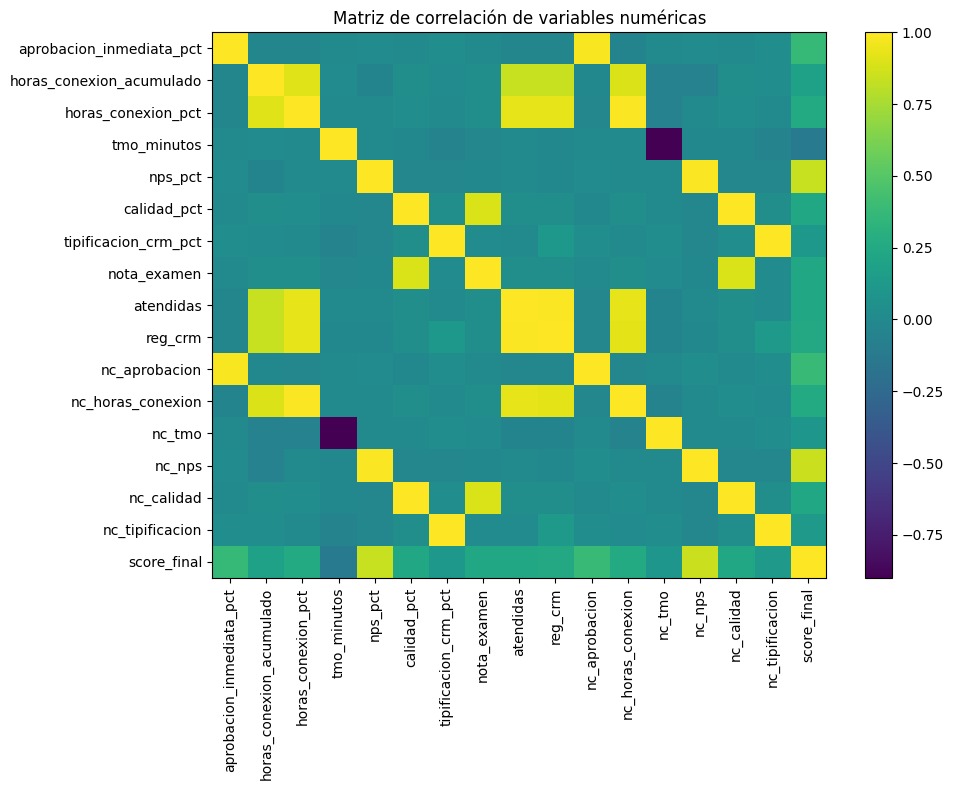

In [27]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

## 18. Validación final para modelamiento

In [28]:
print("Registros para modelo:", df_predictivo.shape[0])
print("Variables disponibles:", df_predictivo.shape[1])

print("\nDistribución variable objetivo:")
print(df_predictivo["semaforo_mes_siguiente"].value_counts(dropna=False))

print("\nNulos en indicadores clave:")
print(df_predictivo[indicadores_clave].isnull().sum())

if "periodo" in df_predictivo.columns:
    print("\nPeriodos disponibles para modelamiento:")
    print(df_predictivo["periodo"].value_counts().sort_index())

Registros para modelo: 1620
Variables disponibles: 37

Distribución variable objetivo:
semaforo_mes_siguiente
Rojo     1068
Ámbar     552
Name: count, dtype: int64

Nulos en indicadores clave:
aprobacion_inmediata_pct    0
horas_conexion_acumulado    0
horas_conexion_pct          0
tmo_minutos                 0
nps_pct                     0
calidad_pct                 0
tipificacion_crm_pct        0
nc_aprobacion               0
nc_horas_conexion           0
nc_tmo                      0
nc_nps                      0
nc_calidad                  0
nc_tipificacion             0
score_final                 0
semaforo_actual             0
semaforo_mes_siguiente      0
dtype: int64

Periodos disponibles para modelamiento:
periodo
2024-01    60
2024-02    60
2024-03    60
2024-04    60
2024-05    60
2024-06    60
2024-07    60
2024-08    60
2024-09    60
2024-10    60
2024-11    60
2024-12    60
2025-01    60
2025-02    60
2025-03    60
2025-04    60
2025-05    60
2025-06    60
2025-07    60

## 19. Exportar resumen del EDA

In [29]:
OUTPUT_DIR = ROOT_DIR / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

resumen_eda = {
    "registros_mensual": [df_mensual.shape[0]],
    "columnas_mensual": [df_mensual.shape[1]],
    "registros_predictivo": [df_predictivo.shape[0]],
    "columnas_predictivo": [df_predictivo.shape[1]],
    "registros_mejora": [df_mejora.shape[0]],
    "columnas_mejora": [df_mejora.shape[1]],
}

df_resumen_eda = pd.DataFrame(resumen_eda)
df_resumen_eda.to_csv(OUTPUT_DIR / "resumen_eda_gold.csv", index=False)

print("Resumen EDA exportado en:", OUTPUT_DIR / "resumen_eda_gold.csv")
df_resumen_eda

Resumen EDA exportado en: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\reports\resumen_eda_gold.csv


,registros_mensual,columnas_mensual,registros_predictivo,columnas_predictivo,registros_mejora,columnas_mejora
0,1680,34,1620,37,10080,12
